In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath("D:\Stocks Risk Analysis"))


<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_11412\2988852484.py:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  sys.path.append(os.path.abspath("D:\Stocks Risk Analysis"))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


In [3]:
df = pd.read_csv("../data/raw/AAPL.csv",skiprows=1)

df.head()


,Unnamed: 0,AAPL,AAPL.1,AAPL.2,AAPL.3,AAPL.4
0,2015-01-02,24.214886,24.682218,23.776346,24.671143,212818400
1,2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2,2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400
3,2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
4,2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [4]:
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

df.head()


,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.214886,24.682218,23.776346,24.671143,212818400
1,2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2,2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400
3,2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
4,2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

numeric_cols = ["Open", "High", "Low", "Close", "Volume"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2264 non-null   datetime64[ns]
 1   Close   2264 non-null   float64       
 2   High    2264 non-null   float64       
 3   Low     2264 non-null   float64       
 4   Open    2264 non-null   float64       
 5   Volume  2264 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 106.3 KB


In [6]:
df = df.sort_values("Date")
df = df.reset_index(drop=True)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2264 non-null   datetime64[ns]
 1   Close   2264 non-null   float64       
 2   High    2264 non-null   float64       
 3   Low     2264 non-null   float64       
 4   Open    2264 non-null   float64       
 5   Volume  2264 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 106.3 KB


In [8]:
df.isnull().sum()


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [9]:
df = df.dropna()


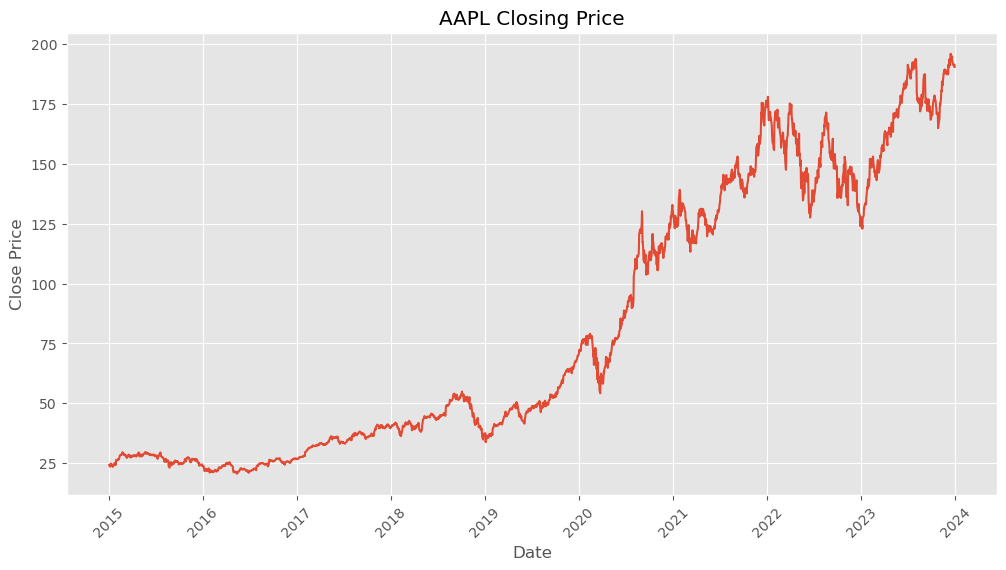

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"])
plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()


In [11]:
df["Daily_Return"] = df["Close"].pct_change()

df.head()


,Date,Close,High,Low,Open,Volume,Daily_Return
0,2015-01-02,24.214886,24.682218,23.776346,24.671143,212818400,NaN
1,2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000,-0.028171
2,2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400,0.000094
3,2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600,0.014022
4,2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000,0.038422


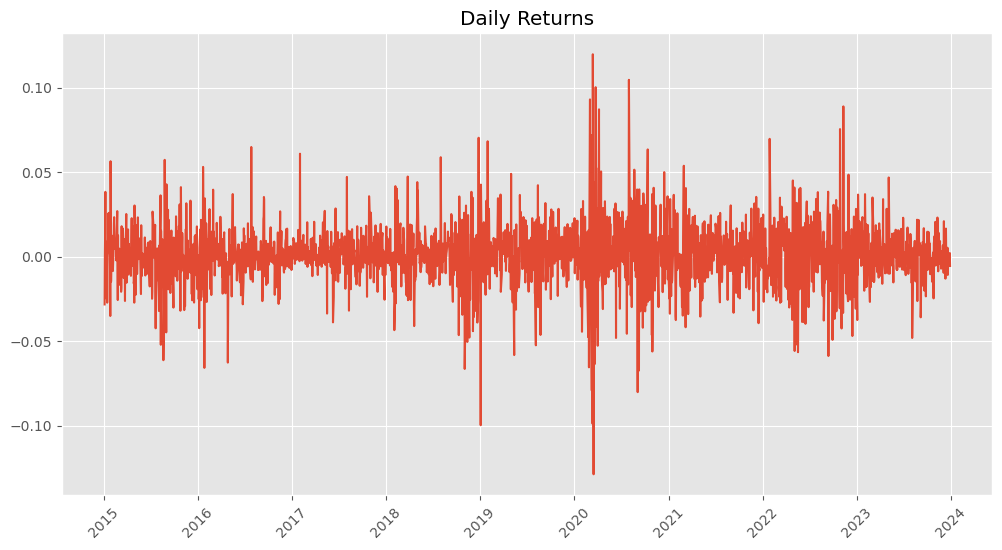

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Daily_Return"])
plt.title("Daily Returns")
plt.xticks(rotation=45)
plt.show()


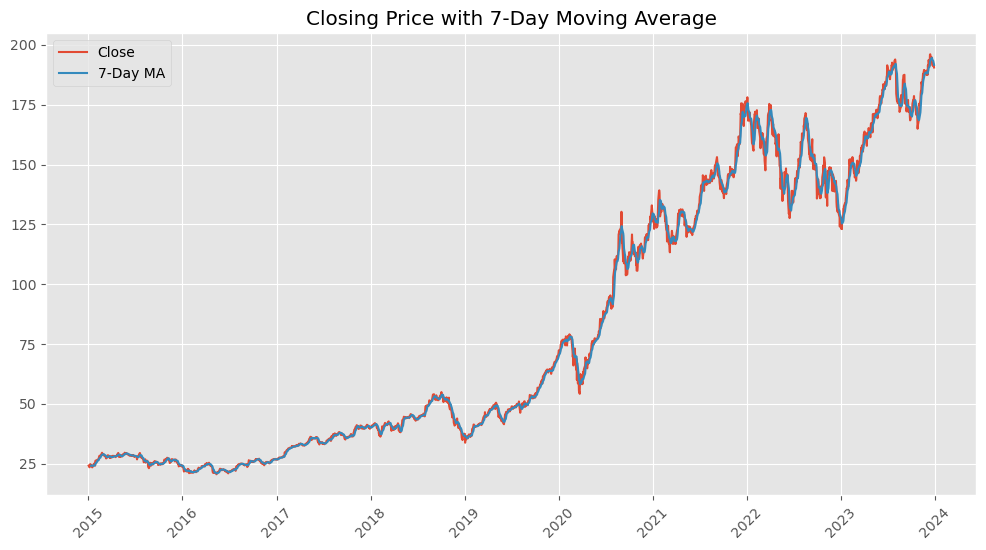

In [13]:
df["Rolling_Mean_7"] = df["Close"].rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["Rolling_Mean_7"], label="7-Day MA")
plt.legend()
plt.title("Closing Price with 7-Day Moving Average")
plt.xticks(rotation=45)
plt.show()


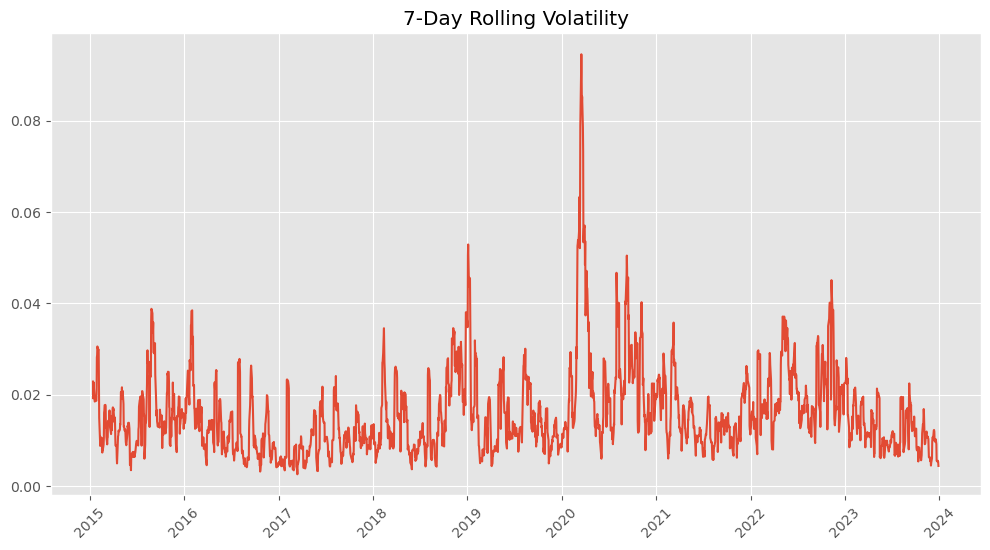

In [14]:
df["Rolling_Std_7"] = df["Daily_Return"].rolling(window=7).std()

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Rolling_Std_7"])
plt.title("7-Day Rolling Volatility")
plt.xticks(rotation=45)
plt.show()


In [15]:
df.to_csv("../data/processed/AAPL_processed.csv", index=False)


In [16]:
df["Daily_Return"] = df["Close"].pct_change()

df.head()


,Date,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean_7,Rolling_Std_7
0,2015-01-02,24.214886,24.682218,23.776346,24.671143,212818400,NaN,NaN,NaN
1,2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000,-0.028171,NaN,NaN
2,2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400,0.000094,NaN,NaN
3,2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600,0.014022,NaN,NaN
4,2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000,0.038422,NaN,NaN


In [17]:
df["MA_7"] = df["Close"].rolling(window=7).mean()
df["MA_30"] = df["Close"].rolling(window=30).mean()


In [18]:
df["Volatility_7"] = df["Daily_Return"].rolling(window=7).std()
df["Volatility_30"] = df["Daily_Return"].rolling(window=30).std()


In [19]:
df["Cumulative_Return"] = (1 + df["Daily_Return"]).cumprod()


In [20]:
df["Rolling_Max"] = df["Close"].cummax()
df["Drawdown"] = df["Close"] / df["Rolling_Max"] - 1


In [21]:
df = df.dropna().reset_index(drop=True)


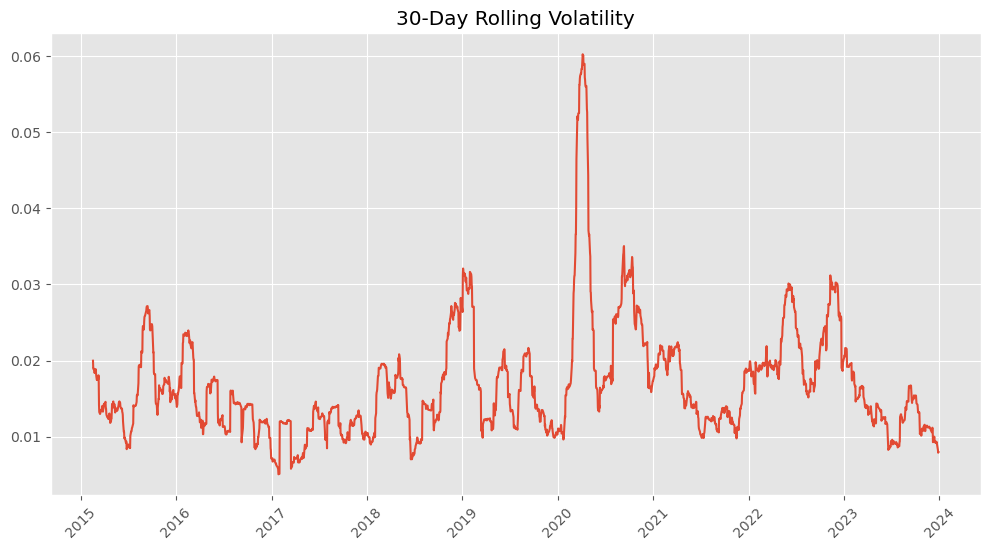

In [22]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Volatility_30"])
plt.title("30-Day Rolling Volatility")
plt.xticks(rotation=45)
plt.show()


In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2234 entries, 0 to 2233
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               2234 non-null   datetime64[ns]
 1   Close              2234 non-null   float64       
 2   High               2234 non-null   float64       
 3   Low                2234 non-null   float64       
 4   Open               2234 non-null   float64       
 5   Volume             2234 non-null   int64         
 6   Daily_Return       2234 non-null   float64       
 7   Rolling_Mean_7     2234 non-null   float64       
 8   Rolling_Std_7      2234 non-null   float64       
 9   MA_7               2234 non-null   float64       
 10  MA_30              2234 non-null   float64       
 11  Volatility_7       2234 non-null   float64       
 12  Volatility_30      2234 non-null   float64       
 13  Cumulative_Return  2234 non-null   float64       
 14  Rolling_

In [25]:
df.to_csv("../data/processed/AAPL_processed.csv", index=False)


In [26]:
def calculate_rsi(data, window=14):
    delta = data["Close"].diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


df["RSI_14"] = calculate_rsi(df)


In [27]:
df["BB_Middle"] = df["Close"].rolling(window=20).mean()
df["BB_Std"] = df["Close"].rolling(window=20).std()

df["BB_Upper"] = df["BB_Middle"] + (2 * df["BB_Std"])
df["BB_Lower"] = df["BB_Middle"] - (2 * df["BB_Std"])


In [28]:
df["Rolling_Return_Mean_30"] = df["Daily_Return"].rolling(30).mean()
df["Rolling_Return_Std_30"] = df["Daily_Return"].rolling(30).std()

df["Sharpe_30"] = df["Rolling_Return_Mean_30"] / df["Rolling_Return_Std_30"]


In [29]:
df = df.dropna().reset_index(drop=True)


In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    2205 non-null   datetime64[ns]
 1   Close                   2205 non-null   float64       
 2   High                    2205 non-null   float64       
 3   Low                     2205 non-null   float64       
 4   Open                    2205 non-null   float64       
 5   Volume                  2205 non-null   int64         
 6   Daily_Return            2205 non-null   float64       
 7   Rolling_Mean_7          2205 non-null   float64       
 8   Rolling_Std_7           2205 non-null   float64       
 9   MA_7                    2205 non-null   float64       
 10  MA_30                   2205 non-null   float64       
 11  Volatility_7            2205 non-null   float64       
 12  Volatility_30           2205 non-null   float64 

In [31]:
# Shift volatility 7 days backward (predict future risk)
df["Future_Volatility_7"] = df["Volatility_7"].shift(-7)


In [32]:
df = df.dropna().reset_index(drop=True)


In [33]:
low_threshold = df["Future_Volatility_7"].quantile(0.33)
high_threshold = df["Future_Volatility_7"].quantile(0.66)

def classify_risk(vol):
    if vol <= low_threshold:
        return 0
    elif vol <= high_threshold:
        return 1
    else:
        return 2

df["Risk_Label"] = df["Future_Volatility_7"].apply(classify_risk)


In [34]:
df["Risk_Label"].value_counts()


Risk_Label
2    747
0    726
1    725
Name: count, dtype: int64

In [35]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2198 entries, 0 to 2197
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    2198 non-null   datetime64[ns]
 1   Close                   2198 non-null   float64       
 2   High                    2198 non-null   float64       
 3   Low                     2198 non-null   float64       
 4   Open                    2198 non-null   float64       
 5   Volume                  2198 non-null   int64         
 6   Daily_Return            2198 non-null   float64       
 7   Rolling_Mean_7          2198 non-null   float64       
 8   Rolling_Std_7           2198 non-null   float64       
 9   MA_7                    2198 non-null   float64       
 10  MA_30                   2198 non-null   float64       
 11  Volatility_7            2198 non-null   float64       
 12  Volatility_30           2198 non-null   float64 

In [36]:
df.to_csv("../data/processed/AAPL_processed.csv", index=False)
